In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os

In [34]:
import urllib.request
url = "https://www.shutterstock.com/image-photo/smiling-young-man-giving-peace-260nw-2601737519.jpg"

urllib.request.urlretrieve(url, "hands.jpg")

('hands.jpg', <http.client.HTTPMessage at 0x766819b1fe30>)

In [35]:
bgr_img = cv2.imread("hands.jpg")
rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)

(np.float64(-0.5), np.float64(461.5), np.float64(279.5), np.float64(-0.5))

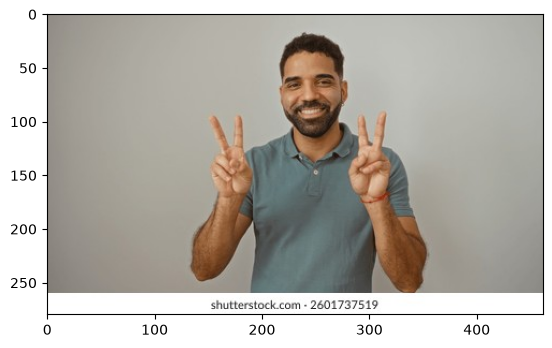

In [36]:
plt.imshow(rgb_img)
plt.axis("on")

In [23]:
base_options = python.BaseOptions(
    model_asset_path="../hand_landmarker.task"
)

options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2
)

detector = vision.HandLandmarker.create_from_options(options)
mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=rgb_img
)

result = detector.detect(mp_image)
#result.hand_ladnmarks is a list - each element is one hand
print(f"Hands detected: {len(result.hand_landmarks)}")

W0000 00:00:1791277173.293225   52552 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1791277173.307444   52552 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Hands detected: 2


(np.float64(-0.5), np.float64(461.5), np.float64(279.5), np.float64(-0.5))

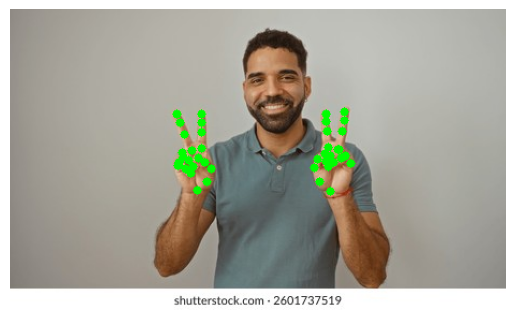

In [24]:
annotated = rgb_img.copy()
h, w, _ = annotated.shape

for hand_landmarks in result.hand_landmarks:
  #landmarks are normalized, so we multiply by img size
    for lm in hand_landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(annotated, (cx, cy), 4, (0, 255, 0), -1)

plt.imshow(annotated)
plt.axis("off")

In [25]:
hand_idx = 0

landmark_idx = 4

lm = result.hand_landmarks[hand_idx][landmark_idx]

print(f"x = {lm.x:.3f}")
print(f"y = {lm.y:.3f}")
print(f"z = {lm.z:.3f}")

x = 0.635
y = 0.481
z = -0.032


In [26]:
if lm.y < 0.5:
    print("Landmark is in the top half of the image")
else:
    print("Landmark is in the bottom half of the image")

Landmark is in the top half of the image


In [27]:
def is_thumbs_up(landmarks):
    thumb_tip = landmarks[4]
    index_tip = landmarks[8]
    middle_tip = landmarks[12]
    ring_tip = landmarks[16]
    pinky_tip = landmarks[20]

    # Thumb must be above all other fingers (smaller y = higher)
    if (
        thumb_tip.y < index_tip.y and
        thumb_tip.y < middle_tip.y and
        thumb_tip.y < ring_tip.y and
        thumb_tip.y < pinky_tip.y
    ):
        return True

    return False

In [28]:
print(is_thumbs_up(result.hand_landmarks[0]))

False


In [29]:
def is_thumbs_down(landmarks):
    thumb_tip = landmarks[4]
    index_tip = landmarks[8]
    middle_tip = landmarks[12]
    ring_tip = landmarks[16]
    pinky_tip = landmarks[20]

    # Thumb must be above all other fingers (smaller y = higher)
    if (
        thumb_tip.y > index_tip.y and
        thumb_tip.y > middle_tip.y and
        thumb_tip.y > ring_tip.y and
        thumb_tip.y > pinky_tip.y
    ):
        return True

    return False

In [30]:
print(is_thumbs_down(result.hand_landmarks[0]))

False


In [31]:
def is_peace_sign(landmarks):
    thumb_tip = landmarks[4]
    index_tip = landmarks[8]
    middle_tip = landmarks[12]
    ring_tip = landmarks[16]
    pinky_tip = landmarks[20]

    if(
        index_tip.y < thumb_tip.y and
        index_tip.y < ring_tip.y and
        index_tip.y < pinky_tip.y and 
        middle_tip.y < thumb_tip.y and
        middle_tip.y < ring_tip.y and
        middle_tip.y < pinky_tip.y 
    ): 
        return True

    return False

In [32]:
print(is_peace_sign(result.hand_landmarks[0]))

True
